# **Black and Scholes Option Pricing**

## imports

In [3]:
# set run path to root 
import sys 
import os 

global_path = '/Users/amjadsaidam/Desktop/Quant stuff /Black and Scholes'
project_root = os.path.abspath(global_path)
code_path = os.path.join(global_path, 'code')

for p in [project_root, code_path]:
    if p not in sys.path:
        sys.path.insert(0, p)

import pandas as pd 
import numpy as np
import os 
from dotenv import load_dotenv 
import databento as db
import matplotlib.pyplot as plt
# custom modules 
from data.databento_api_request import DatabentoAsset
import black_scholes_model as bs

## Data

In [13]:
# get key 
load_dotenv(dotenv_path = 'databento_functions/databento_api_key.env')
api_key = os.environ.get('APIKEY')

# define variables
underlying = 'NVDA'

end_date = pd.Timestamp.today() - pd.Timedelta(days = 4)
start_date_o = end_date - pd.Timedelta(days = 1) # last day of data in order not to invalidate free plan constraints

start_date_e = end_date - pd.Timedelta(days = 365) # approx 252
print('maximum option time series length', end_date - start_date_o)
print('equity option time series length', end_date  - start_date_e)

db_data: DatabentoAsset = DatabentoAsset(api_key, underlying, end_date)
equity_option_chain = db_data.option_equity_schema(start_date_o)
equity_data = db_data.equity_schema(start_date_e)

maximum option time series length 1 days 00:00:00
equity option time series length 365 days 00:00:00


/Users/amjadsaidam/Desktop/Quant stuff /Black and Scholes/databento_functions/databento_api_request.py:20: BentoWarning: The request time range does not start at UTC midnight, instrument definitions effective on this date may be missing. See: https://databento.com/docs/schemas-and-data-formats/instrument-definitions#snapshots
  data = self.client.timeseries.get_range(


In [15]:
equity_option_chain

,ts_event,rtype,publisher_id,instrument_id,raw_symbol,security_update_action,instrument_class,min_price_increment,display_factor,expiration,...,sub_fraction,underlying_product,maturity_month,maturity_day,maturity_week,user_defined_instrument,contract_multiplier_unit,flow_schedule_type,tick_rule,symbol
ts_recv,,,,,,,,,,,,,,,,,,,,,
2026-06-12 10:30:00.623041671+00:00,2026-06-12 10:30:00.622840502+00:00,19,30,855638017,NVDA 270115P00135000,A,P,NaN,NaN,2027-01-15 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 270115P00135000
2026-06-12 10:30:00.623056062+00:00,2026-06-12 10:30:00.622855290+00:00,19,30,855638018,NVDA 270115P00190000,A,P,NaN,NaN,2027-01-15 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 270115P00190000
2026-06-12 10:30:00.633245359+00:00,2026-06-12 10:30:00.633044623+00:00,19,30,855638019,NVDA 270617P00165000,A,P,NaN,NaN,2027-06-17 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 270617P00165000
2026-06-12 10:30:00.633265252+00:00,2026-06-12 10:30:00.633064626+00:00,19,30,855638020,NVDA 270617P00010000,A,P,NaN,NaN,2027-06-17 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 270617P00010000
2026-06-12 10:30:00.643284210+00:00,2026-06-12 10:30:00.643083468+00:00,19,30,855638021,NVDA 270617P00230000,A,P,NaN,NaN,2027-06-17 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 270617P00230000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-12 12:00:00.279091174+00:00,2026-06-12 12:00:00.278890591+00:00,19,30,855638909,NVDA 260731P00130000,A,P,NaN,NaN,2026-07-31 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 260731P00130000
2026-06-12 12:00:00.281092662+00:00,2026-06-12 12:00:00.280891806+00:00,19,30,855638910,NVDA 260731P00105000,A,P,NaN,NaN,2026-07-31 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 260731P00105000
2026-06-12 12:00:00.319592716+00:00,2026-06-12 12:00:00.319392081+00:00,19,30,855638911,NVDA 260731P00325000,A,P,NaN,NaN,2026-07-31 00:00:00+00:00,...,255,255,255,255,255,N,127,127,255,NVDA 260731P00325000


## EDA

In [16]:
from collections import defaultdict
data_by_instrument = defaultdict()
for o_type in ['C', 'P']:
    data_by_instrument[o_type] = equity_option_chain.loc[(equity_option_chain['instrument_class'] == 'C') & 
    (equity_option_chain['security_update_action'] != 'D'), :] # keep valid sitting orders 

# most recent call and put orders 
top_valid_call = data_by_instrument['C'].iloc[-1, :]
top_valid_put = data_by_instrument['P'].iloc[-1, :]

# times 
time_date = equity_option_chain.loc[:, 'ts_event'].dt.strftime('%y-%m-%d') 
min_time = time_date.iloc[0]
max_time = time_date.iloc[-1] # current top of chain time 

## Pricing Options Under Black and Scholes 

In [19]:
# parameters and vars 
equity_rt = equity_data['close'].pct_change().fillna(0).values
s0 = equity_data['close'].iloc[-1]
r = 4.3e-2

t0 = top_valid_call.ts_event
T = top_valid_call.expiration 
bdays = pd.bdate_range(t0, T).shape[0]
print('number of businnes days until option expirey', bdays)

number of businnes days until option expirey 36


In [ ]:
# model
bs_model = bs.BlackScholesOptionPricing(
    current_underlying_price = s0, 
    underlying_returns = equity_rt,
    risk_free_rate = r
)

# strikes
call_k = top_valid_call.strike_price
put_k = top_valid_put.strike_price

# call and put premiums
call_prem = bs_model.call_option_price(call_k, 
                                       current_time = 0, 
                                       option_creation_time = top_valid_call.ts_event, 
                                       expiration_time = top_valid_call.expiration)
put_prem = bs_model.put_option_price(put_k, 
                                     current_time = 0, 
                                     option_creation_time = top_valid_put.ts_event, 
                                     expiration_time = top_valid_put.expiration)

# predictions 
print(f'Call Price, S0={s0}, K={call_k}, V={call_prem}')
print(f'Put Price, S0={s0}, K={put_k}, V={put_prem}')

Call Price, S0=205.4, K=140.0, V=66.28249028049123
Put Price, S0=205.4, K=140.0, V=0.025126308719144008


### Option Payoffs

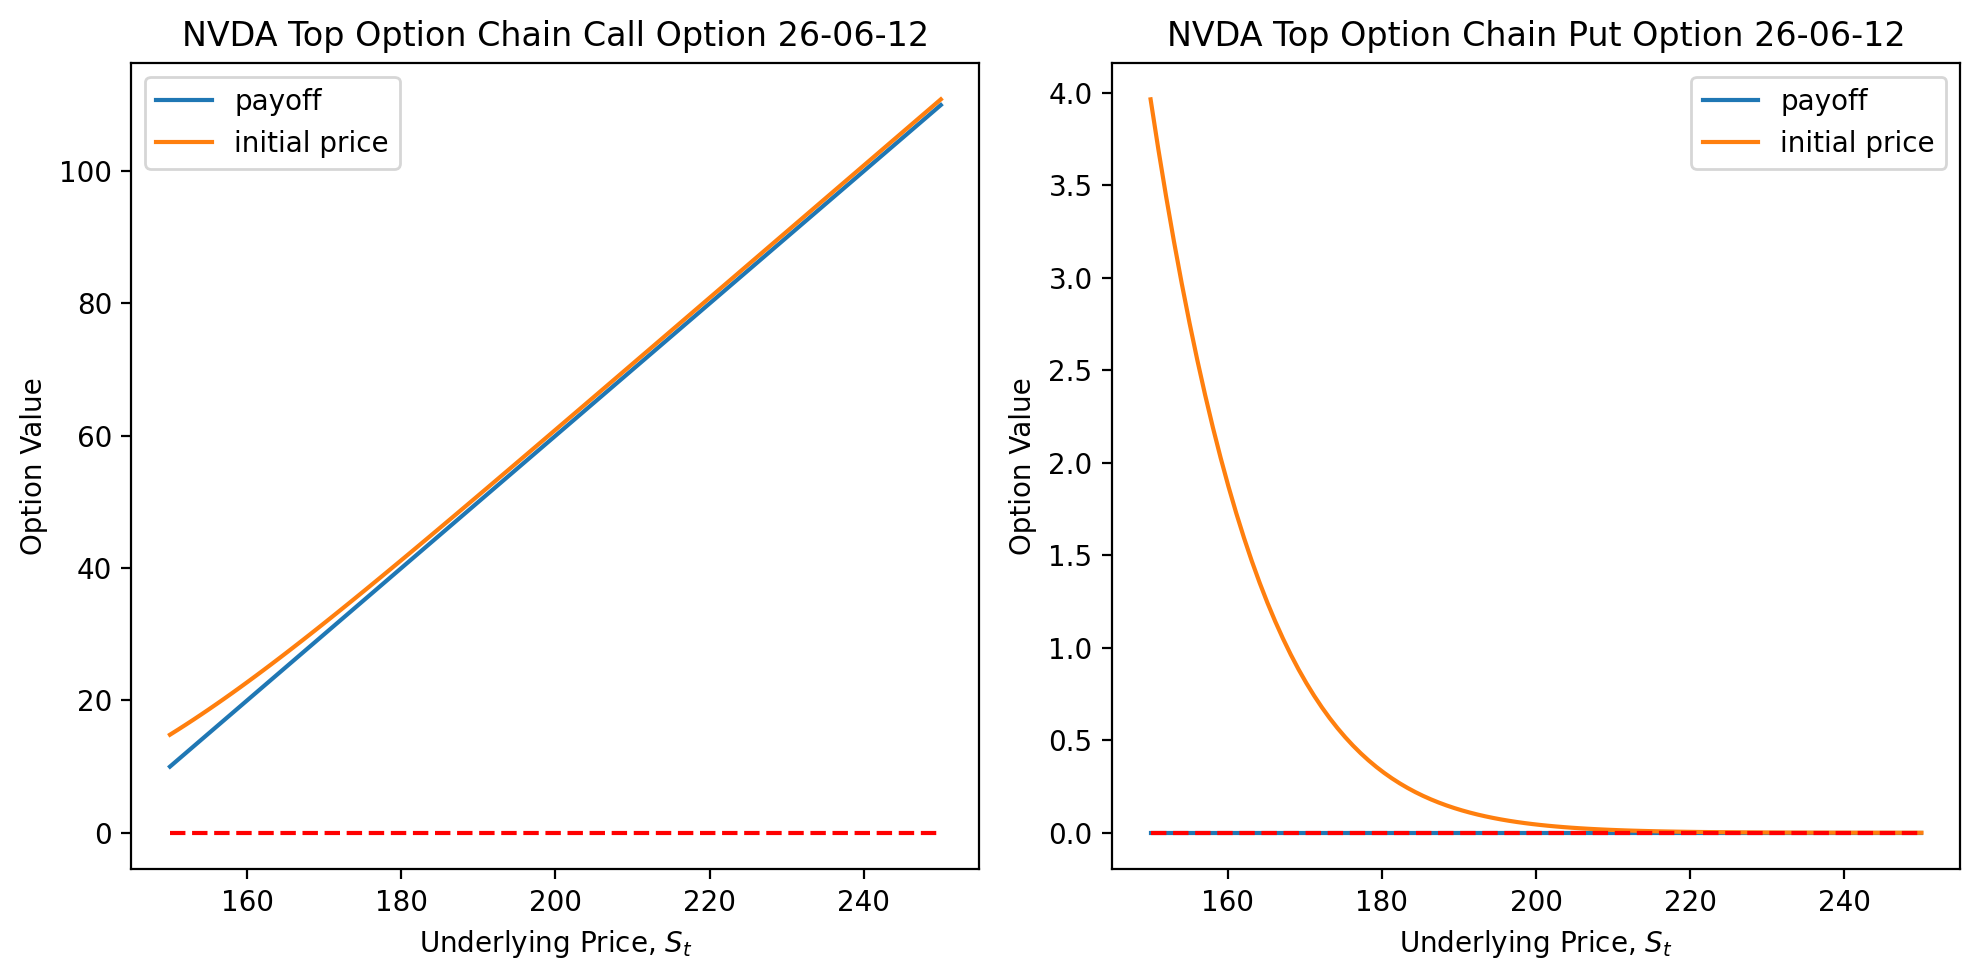

In [ ]:
# call/put payoff at expirey 
smin, smax = 150, 250
stock_prices = np.linspace(smin, smax, 100)
call_payoff_T = bs.call_payoff(stock_prices, call_k, 0)
put_payoff_T = bs.put_payoff(stock_prices, put_k, 0)

# initial call/put price
call_t0 = []
put_t0 = []
for st in stock_prices: 
    bs_model = bs.BlackScholesOptionPricing(st, equity_rt, risk_free_rate = r)
    call_t0.append(bs_model.call_option_price(call_k, 0, top_valid_call.ts_event, top_valid_call.expiration))
    put_t0.append(bs_model.put_option_price(put_k, 0, top_valid_put.ts_event, top_valid_put.expiration))

# plot payoffs
plt.style.use('default')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (10, 5), dpi = 200)
# call
ax[0].set_title(f'{underlying} Top Option Chain Call Option {max_time}')
ax[0].plot(stock_prices, call_payoff_T)
ax[0].plot(stock_prices, call_t0)
ax[0].hlines(0, smin, smax, color = 'r', linestyle = '--')
ax[0].set_ylabel('Option Value')
ax[0].set_xlabel('Underlying Price, $S_t$')
ax[0].legend(['payoff', 'initial price'])
# put
ax[1].set_title(f'{underlying} Top Option Chain Put Option {max_time}')
ax[1].plot(stock_prices, put_payoff_T)
ax[1].plot(stock_prices, put_t0)
ax[1].hlines(0, smin, smax, color = 'r', linestyle = '--')
ax[1].set_ylabel('Option Value')
ax[1].set_xlabel('Underlying Price, $S_t$')
ax[1].legend(['payoff', 'initial price'])
plt.tight_layout();

## Option Premium Surface

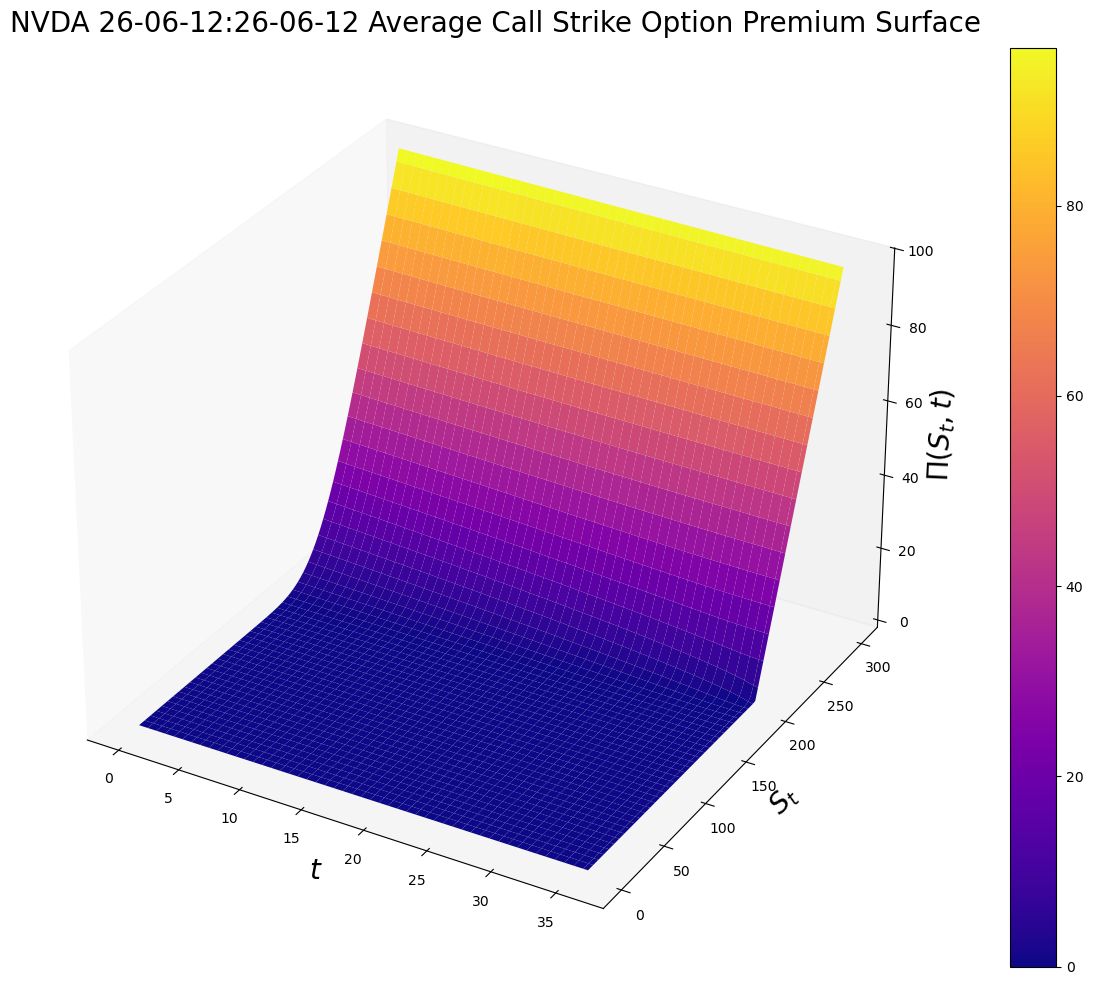

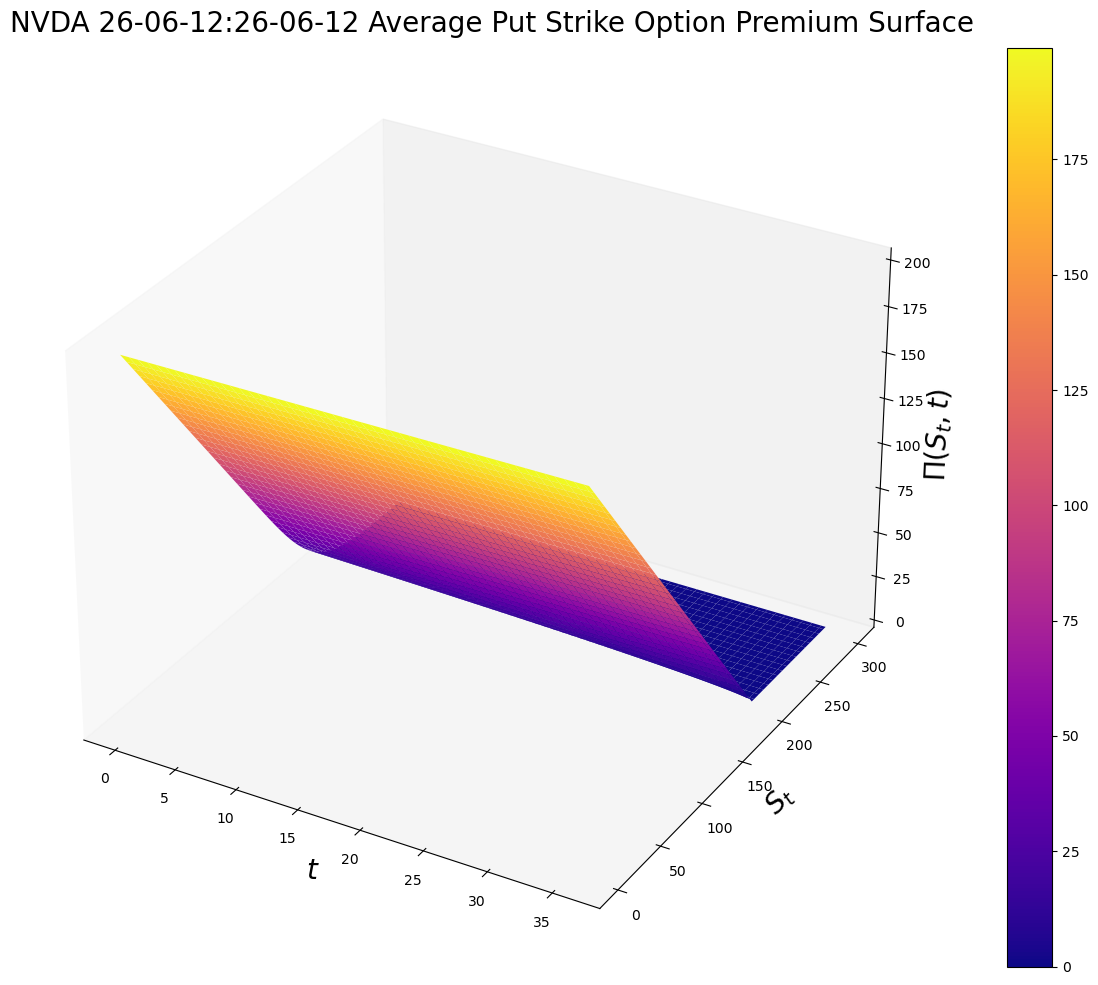

In [ ]:
# get average strikes
avg_call_strike = data_by_instrument['C'].loc[:, ['strike_price']].values.mean()
avg_put_strike = data_by_instrument['P'].loc[:, ['strike_price']].values.mean()

# plot     
stock_prices = np.linspace(1, 300, 100)
times = np.linspace(0, bdays, 100) # avoid division by zero

titles = [
    f'{underlying} {min_time}:{max_time} Average Call Strike Option Premium Surface', 
    f'{underlying} {min_time}:{max_time} Average Put Strike Option Premium Surface'
]

call_surface = bs.OptionPremiumSurface(stock_prices, times, top_valid_call, top_valid_put, 'call', titles[0])
put_surface = bs.OptionPremiumSurface(stock_prices, times, top_valid_call, top_valid_put, 'put', titles[1])

# plot surface 
for i, opt in enumerate([call_surface, put_surface]):
    plt.style.use('default')
    fig = plt.figure(figsize = (15, 10))
    fig.suptitle(titles[i], fontsize = 20)
    ax = fig.add_subplot(projection = '3d')
    surf = ax.plot_surface(opt['times_axis'], opt['price_axis'], opt['value_axis'], cmap = 'plasma')
    ax.set_xlabel('$t$', fontsize = 20)
    ax.set_ylabel('$S_t$', fontsize = 20)
    ax.set_zlabel(r'$\Pi(S_t, t)$', fontsize = 20)
    ax.grid(False)
    fig.colorbar(surf)
    plt.tight_layout()
    plt.show();

## Option Greeks

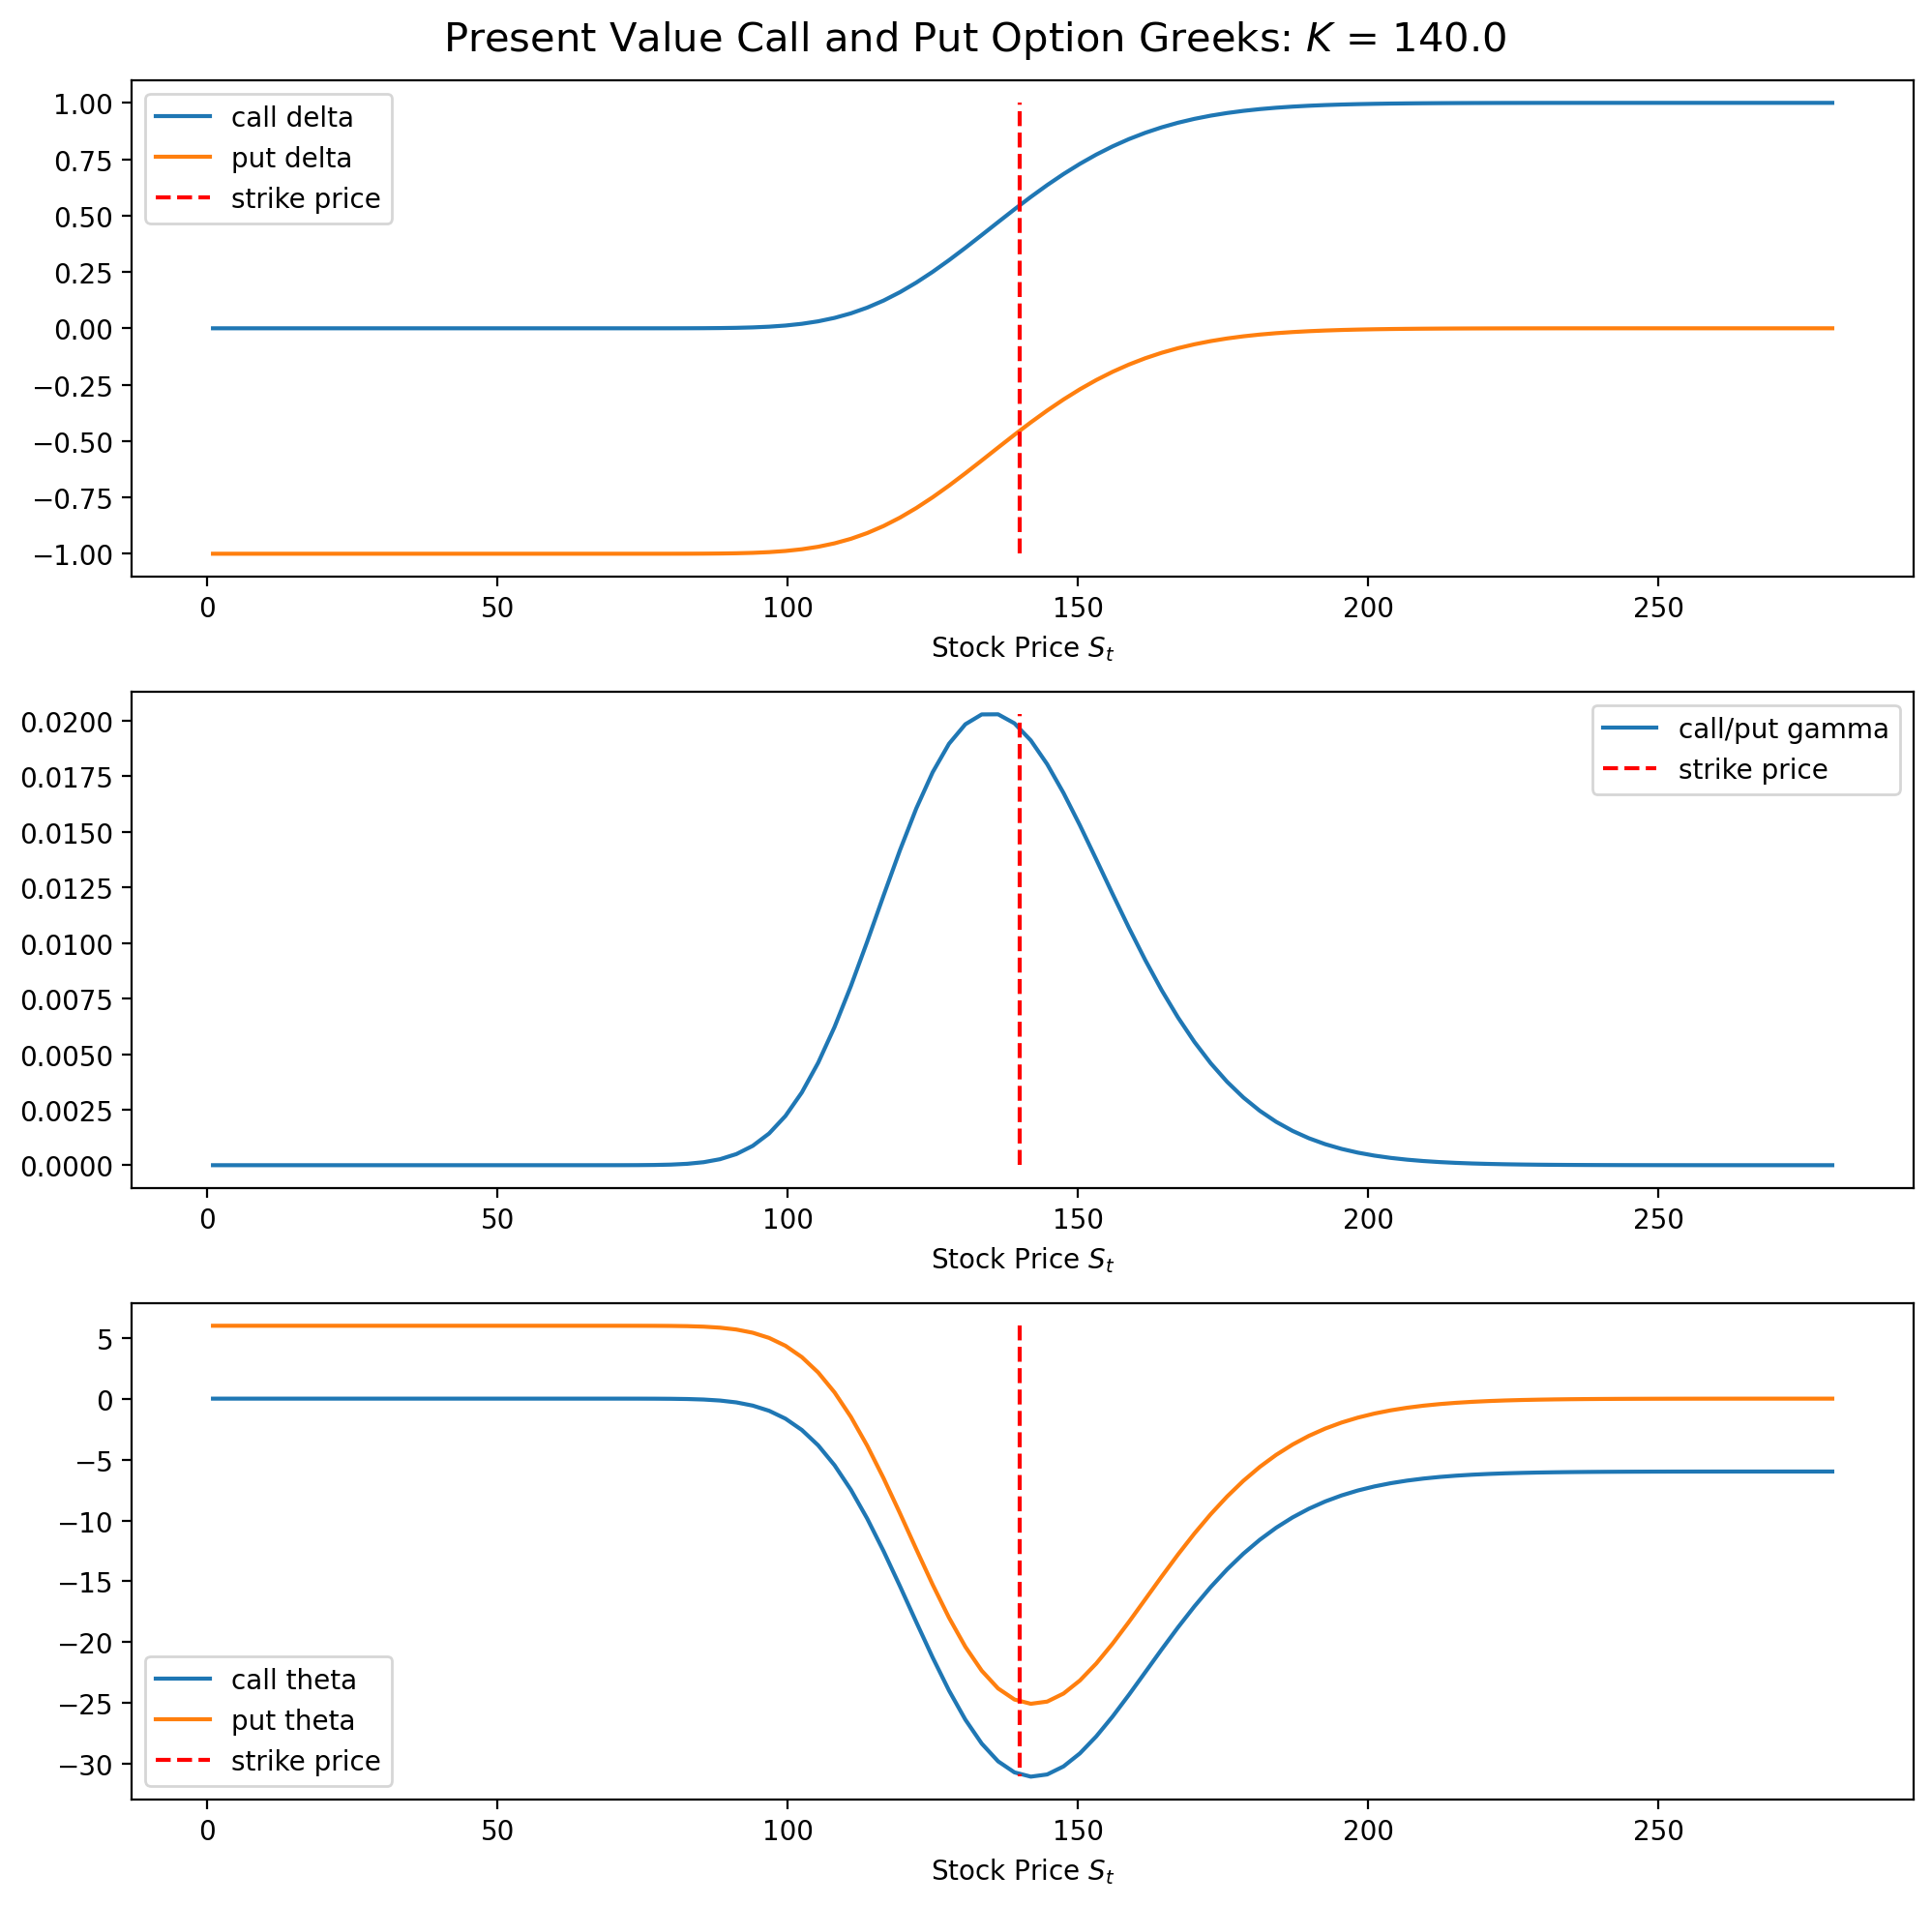

In [ ]:
def greeks(bs_model: bs.BlackScholesOptionPricing, 
           stock_prices, 
           strike_price, 
           option_creation_time, 
           option_expiration_time, 
           option_type: str = 'call'):
    """
    calculates the greeks for a list of stock prices
    """
    t0 = 0
    greeks = {'delta': [], 'gamma': [], 'theta': []}

    for st in stock_prices: 
        bs_model.st = st
        greeks['delta'].append(
            bs_model.delta(strike_price, t0, option_creation_time, option_expiration_time, option_type)
        )
        greeks['gamma'].append(
            bs_model.gamma(strike_price, st, t0, option_creation_time, option_expiration_time)
        )
        greeks['theta'].append(
            bs_model.theta(strike_price, st, t0, option_creation_time, option_expiration_time, option_type)
        )
    
    return greeks

# initilise
stock_prices = np.linspace(1, call_k*2, 100)
o_greeks_c = greeks(bs_model, stock_prices, call_k, top_valid_call.ts_event, top_valid_call.expiration)
o_greeks_p = greeks(bs_model, stock_prices, put_k, top_valid_put.ts_event, top_valid_put.expiration, 'put')

# plot 
fig, ax = plt.subplots(nrows = 3, ncols = 1, figsize = (10, 10), dpi = 200)
fig.suptitle(f'Present Value Call and Put Option Greeks: $K$ = {call_k}', fontsize = 15)

ax[0].plot(stock_prices, o_greeks_c['delta'], label = 'call delta')
ax[0].plot(stock_prices, o_greeks_p['delta'], label = 'put delta')
ax[0].vlines(call_k, -1, 1, color = 'r', linestyle = '--', label = 'strike price')

ax[0].set_xlabel(r'Stock Price $S_t$')
ax[0].legend()

ax[1].plot(stock_prices, o_greeks_c['gamma'], label = 'call/put gamma')
ax[1].vlines(call_k, 0, max(o_greeks_c['gamma']), color = 'r', linestyle = '--', label = 'strike price')
ax[1].set_xlabel(r'Stock Price $S_t$')
ax[1].legend()

ax[2].plot(stock_prices, o_greeks_c['theta'], label = 'call theta')
ax[2].plot(stock_prices, o_greeks_p['theta'], label = 'put theta')
ax[2].vlines(call_k, max(o_greeks_p['theta']), min(o_greeks_c['theta']), color = 'r', linestyle = '--', label = 'strike price')
ax[2].set_xlabel(r'Stock Price $S_t$')
ax[2].legend()

plt.tight_layout();
    

## Option Hedging

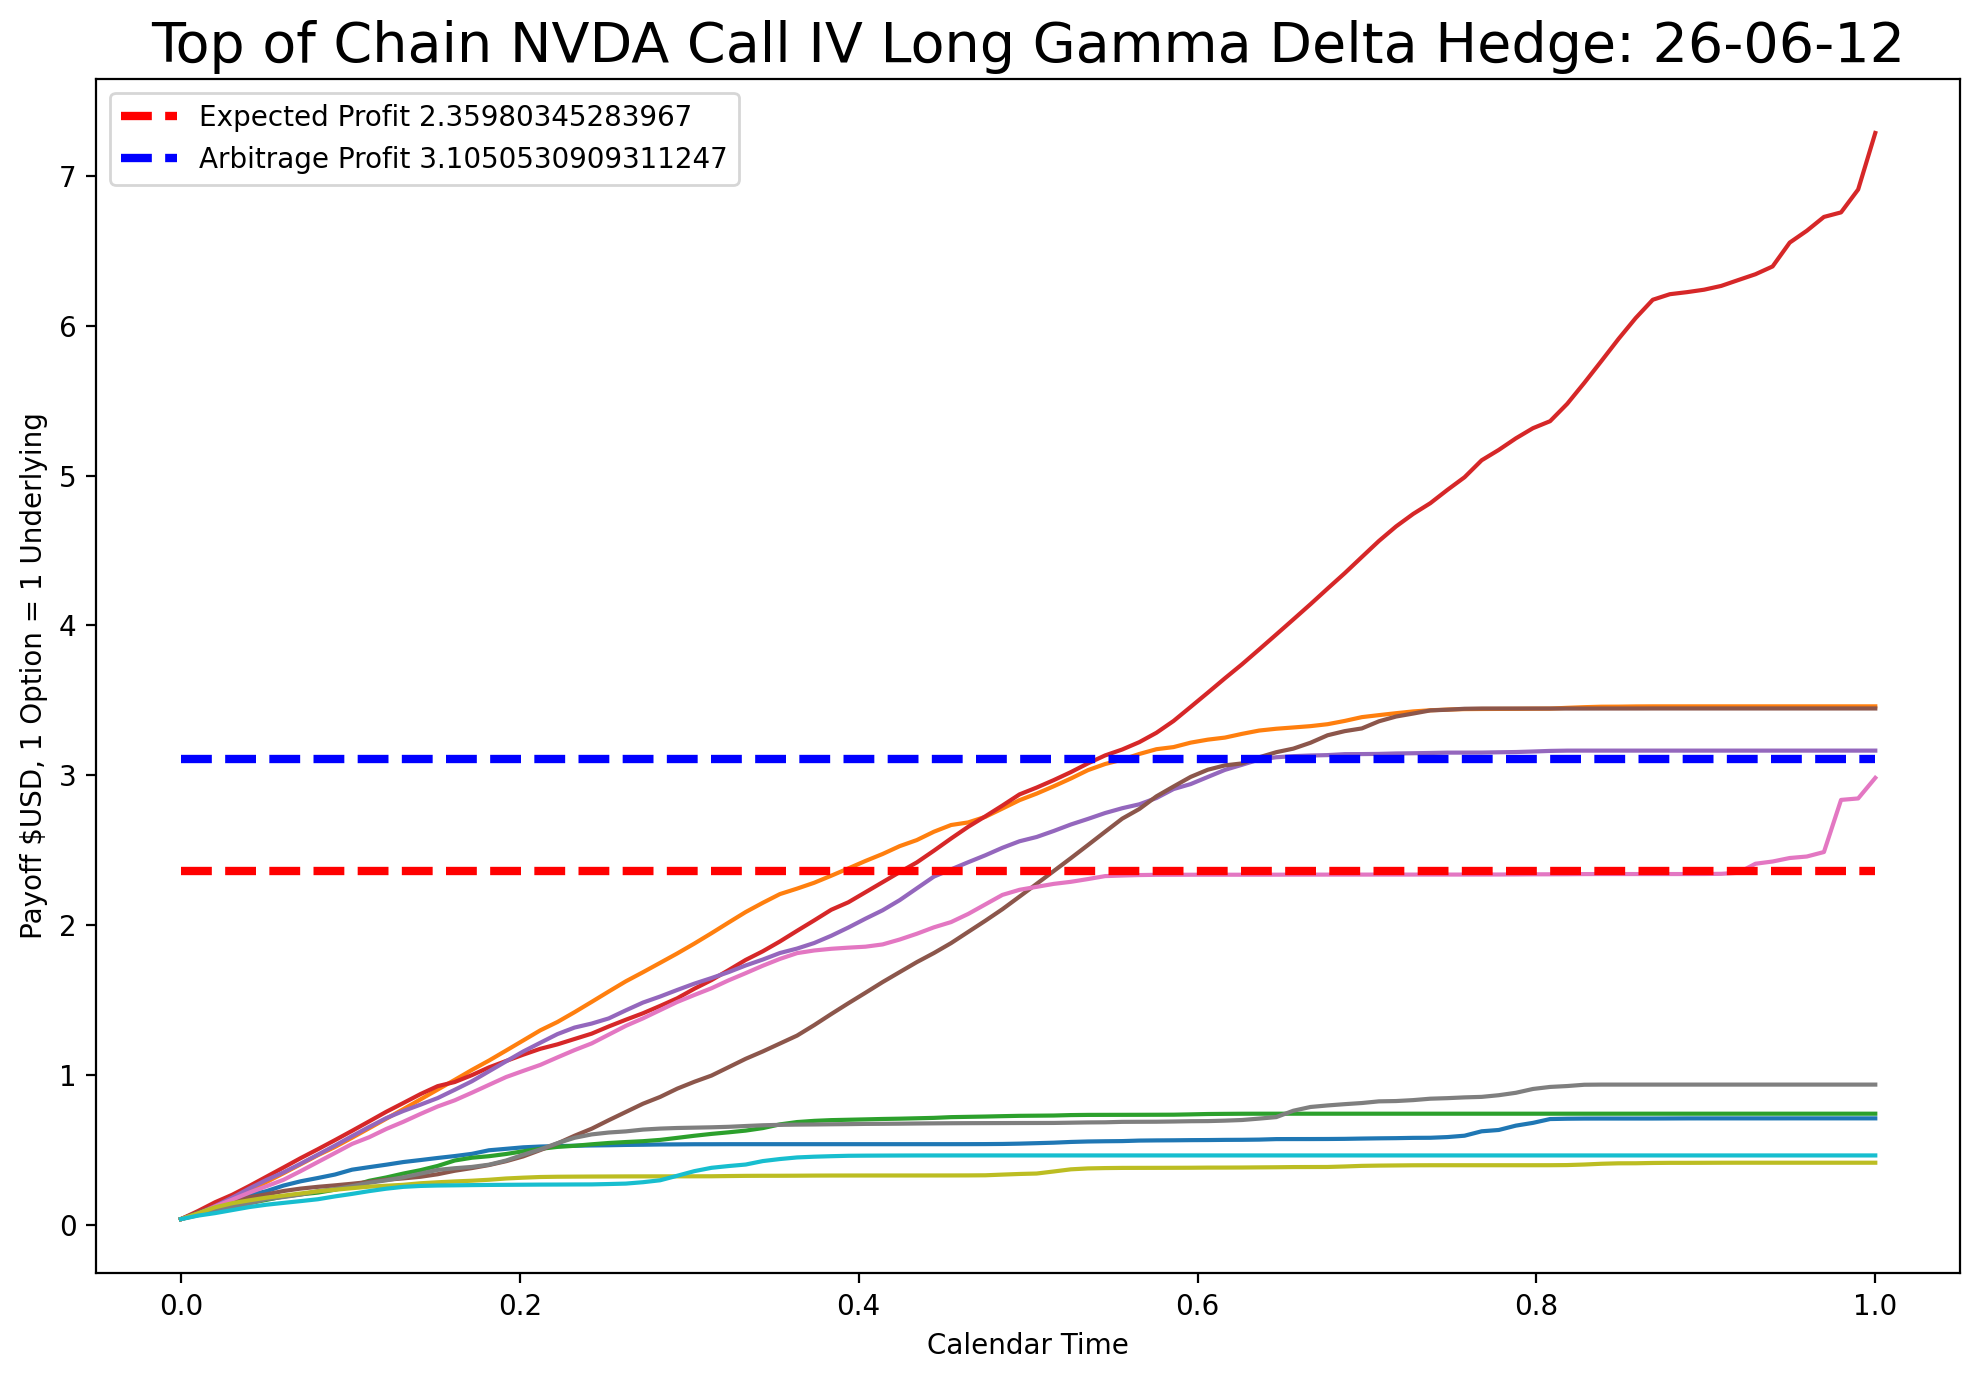

In [ ]:
paths = 10 # number of independent simulations 
sims = 100 # points per simulationn
tte = np.linspace(0, 1, sims)

bs_model = bs.BlackScholesOptionPricing(s0, equity_rt)
hedge: bs.Hedging = bs.Hedging(equity_rt)

bs_model.iv = bs_model.std/2 # iv < rv -> long delta hedge 
bs_model.st = call_k - 10
delta_iv_hedge = hedge.delta_gamma_hedge(bs_model.iv,
                    call_k, 
                    bs_model.st, 
                    top_valid_call.ts_event, 
                    top_valid_call.expiration,
                    paths = paths, 
                    hedging_points = sims)

# calculate expected profit and arbitrage theoretical profit (arb expected profit should converge to arbitrage profit in the limit)
Va = bs_model.call_option_price(call_k, 0, top_valid_call.ts_event, top_valid_call.expiration)
Vi = bs_model.call_option_price(call_k, 0, top_valid_call.ts_event, top_valid_call.expiration, True)

arb_pnl = np.exp(bs_model.r*bdays/252)*(Va - Vi)
exp_pnl = np.mean(delta_iv_hedge['final_pnl'], axis = -1)

# plot 
fig, ax  = plt.subplots(figsize = (10, 7), dpi = 200)
plt.title(f'Top of Chain {underlying} Call IV Long Gamma Delta Hedge: {max_time}', fontsize = 20)
plt.plot(tte, delta_iv_hedge['hedge_pnl_paths'])
plt.xlabel('Calendar Time')
plt.ylabel('Payoff $USD, 1 Option = 1 Underlying')
# labels 
plt.hlines(exp_pnl, 0, 1, color = 'r', linestyle = '--', linewidth = 3, label = f'Expected Profit {exp_pnl}')
plt.hlines(arb_pnl, 0, 1, color = 'b', linestyle = '--', linewidth = 3, label = f'Arbitrage Profit {arb_pnl}')
plt.legend()
plt.tight_layout();

### Long-gamma Implied Volatility Total Profit Surface 

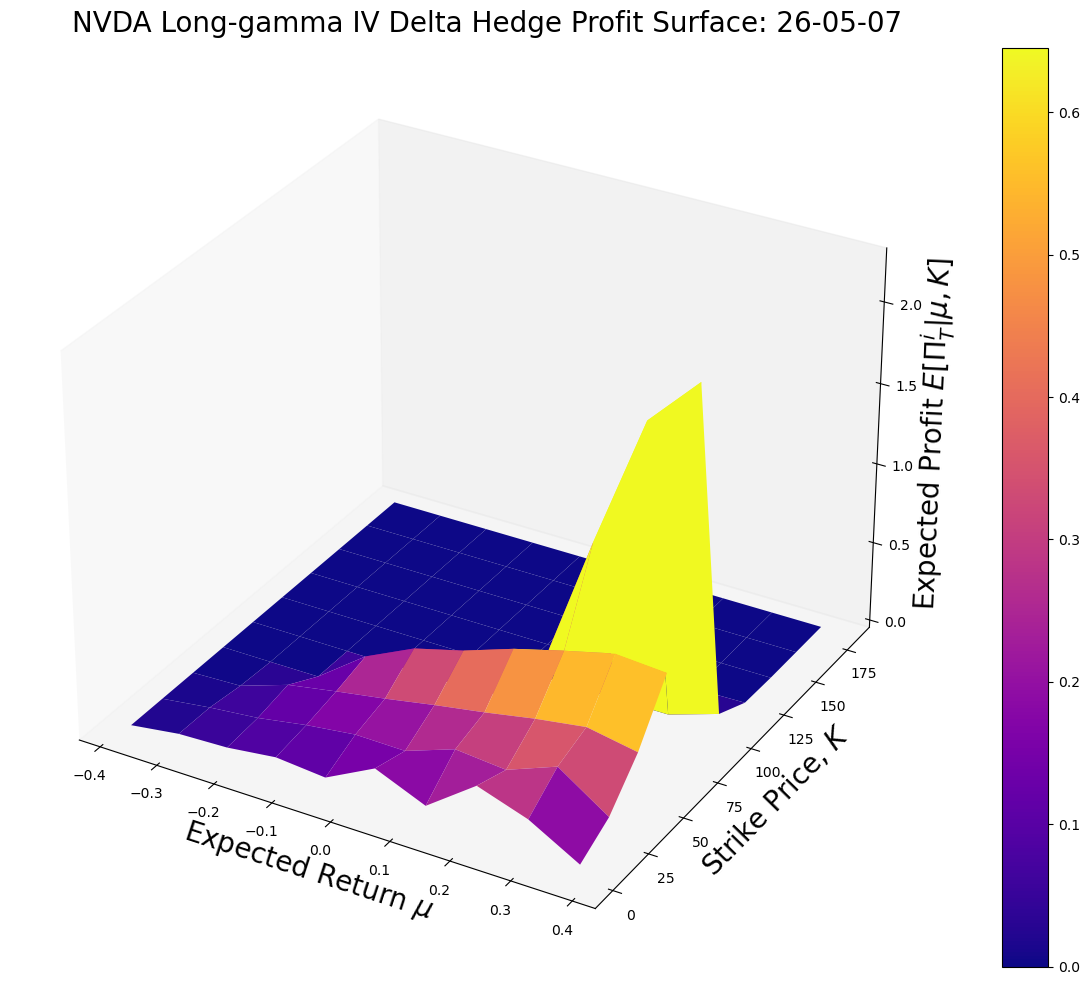

In [ ]:
# call
mu = np.mean(equity_rt, axis = -1)
top_mu = mu + bs_model.std

mu_list = np.linspace(-top_mu, top_mu, 10)
k_list = np.linspace(1, call_k, 10)

call_opt_delta_hedge = bs.DeltaHedgeProfitSurface(equity_rt, 
                           mu_list, 
                           k_list, 
                           s0, 
                           top_valid_call.ts_event, 
                           top_valid_call.expiration, 
                           paths_per_point = 100, 
                           implied_volatility = bs_model.std/1.5)

# plot 
fig = plt.figure(figsize = (15, 10))
fig.suptitle(f'{underlying} Call Long-gamma IV Delta Hedge Profit Surface: {max_time}', fontsize = 20)
ax = fig.add_subplot(projection = '3d')
vmin = np.percentile(call_opt_delta_hedge['pnl_surface'], 5)
vmax = np.percentile(call_opt_delta_hedge['pnl_surface'], 95)
pnl_surf = ax.plot_surface(
    call_opt_delta_hedge['growth_rate_axis'], 
    call_opt_delta_hedge['strike_price_axis'], 
    call_opt_delta_hedge['pnl_surface'], vmin = vmin, vmax = vmax, cmap = 'plasma')
fig.colorbar(pnl_surf)
ax.set_xlabel(r'Expected Return $\mu$', fontsize = 20)
ax.set_ylabel(r'Strike Price, $K$', fontsize = 20)
ax.set_zlabel(r'Expected Profit $E[\Pi_T^i | \mu, K]$', fontsize = 20)
ax.grid(False)
plt.tight_layout()
plt.show();

contour map

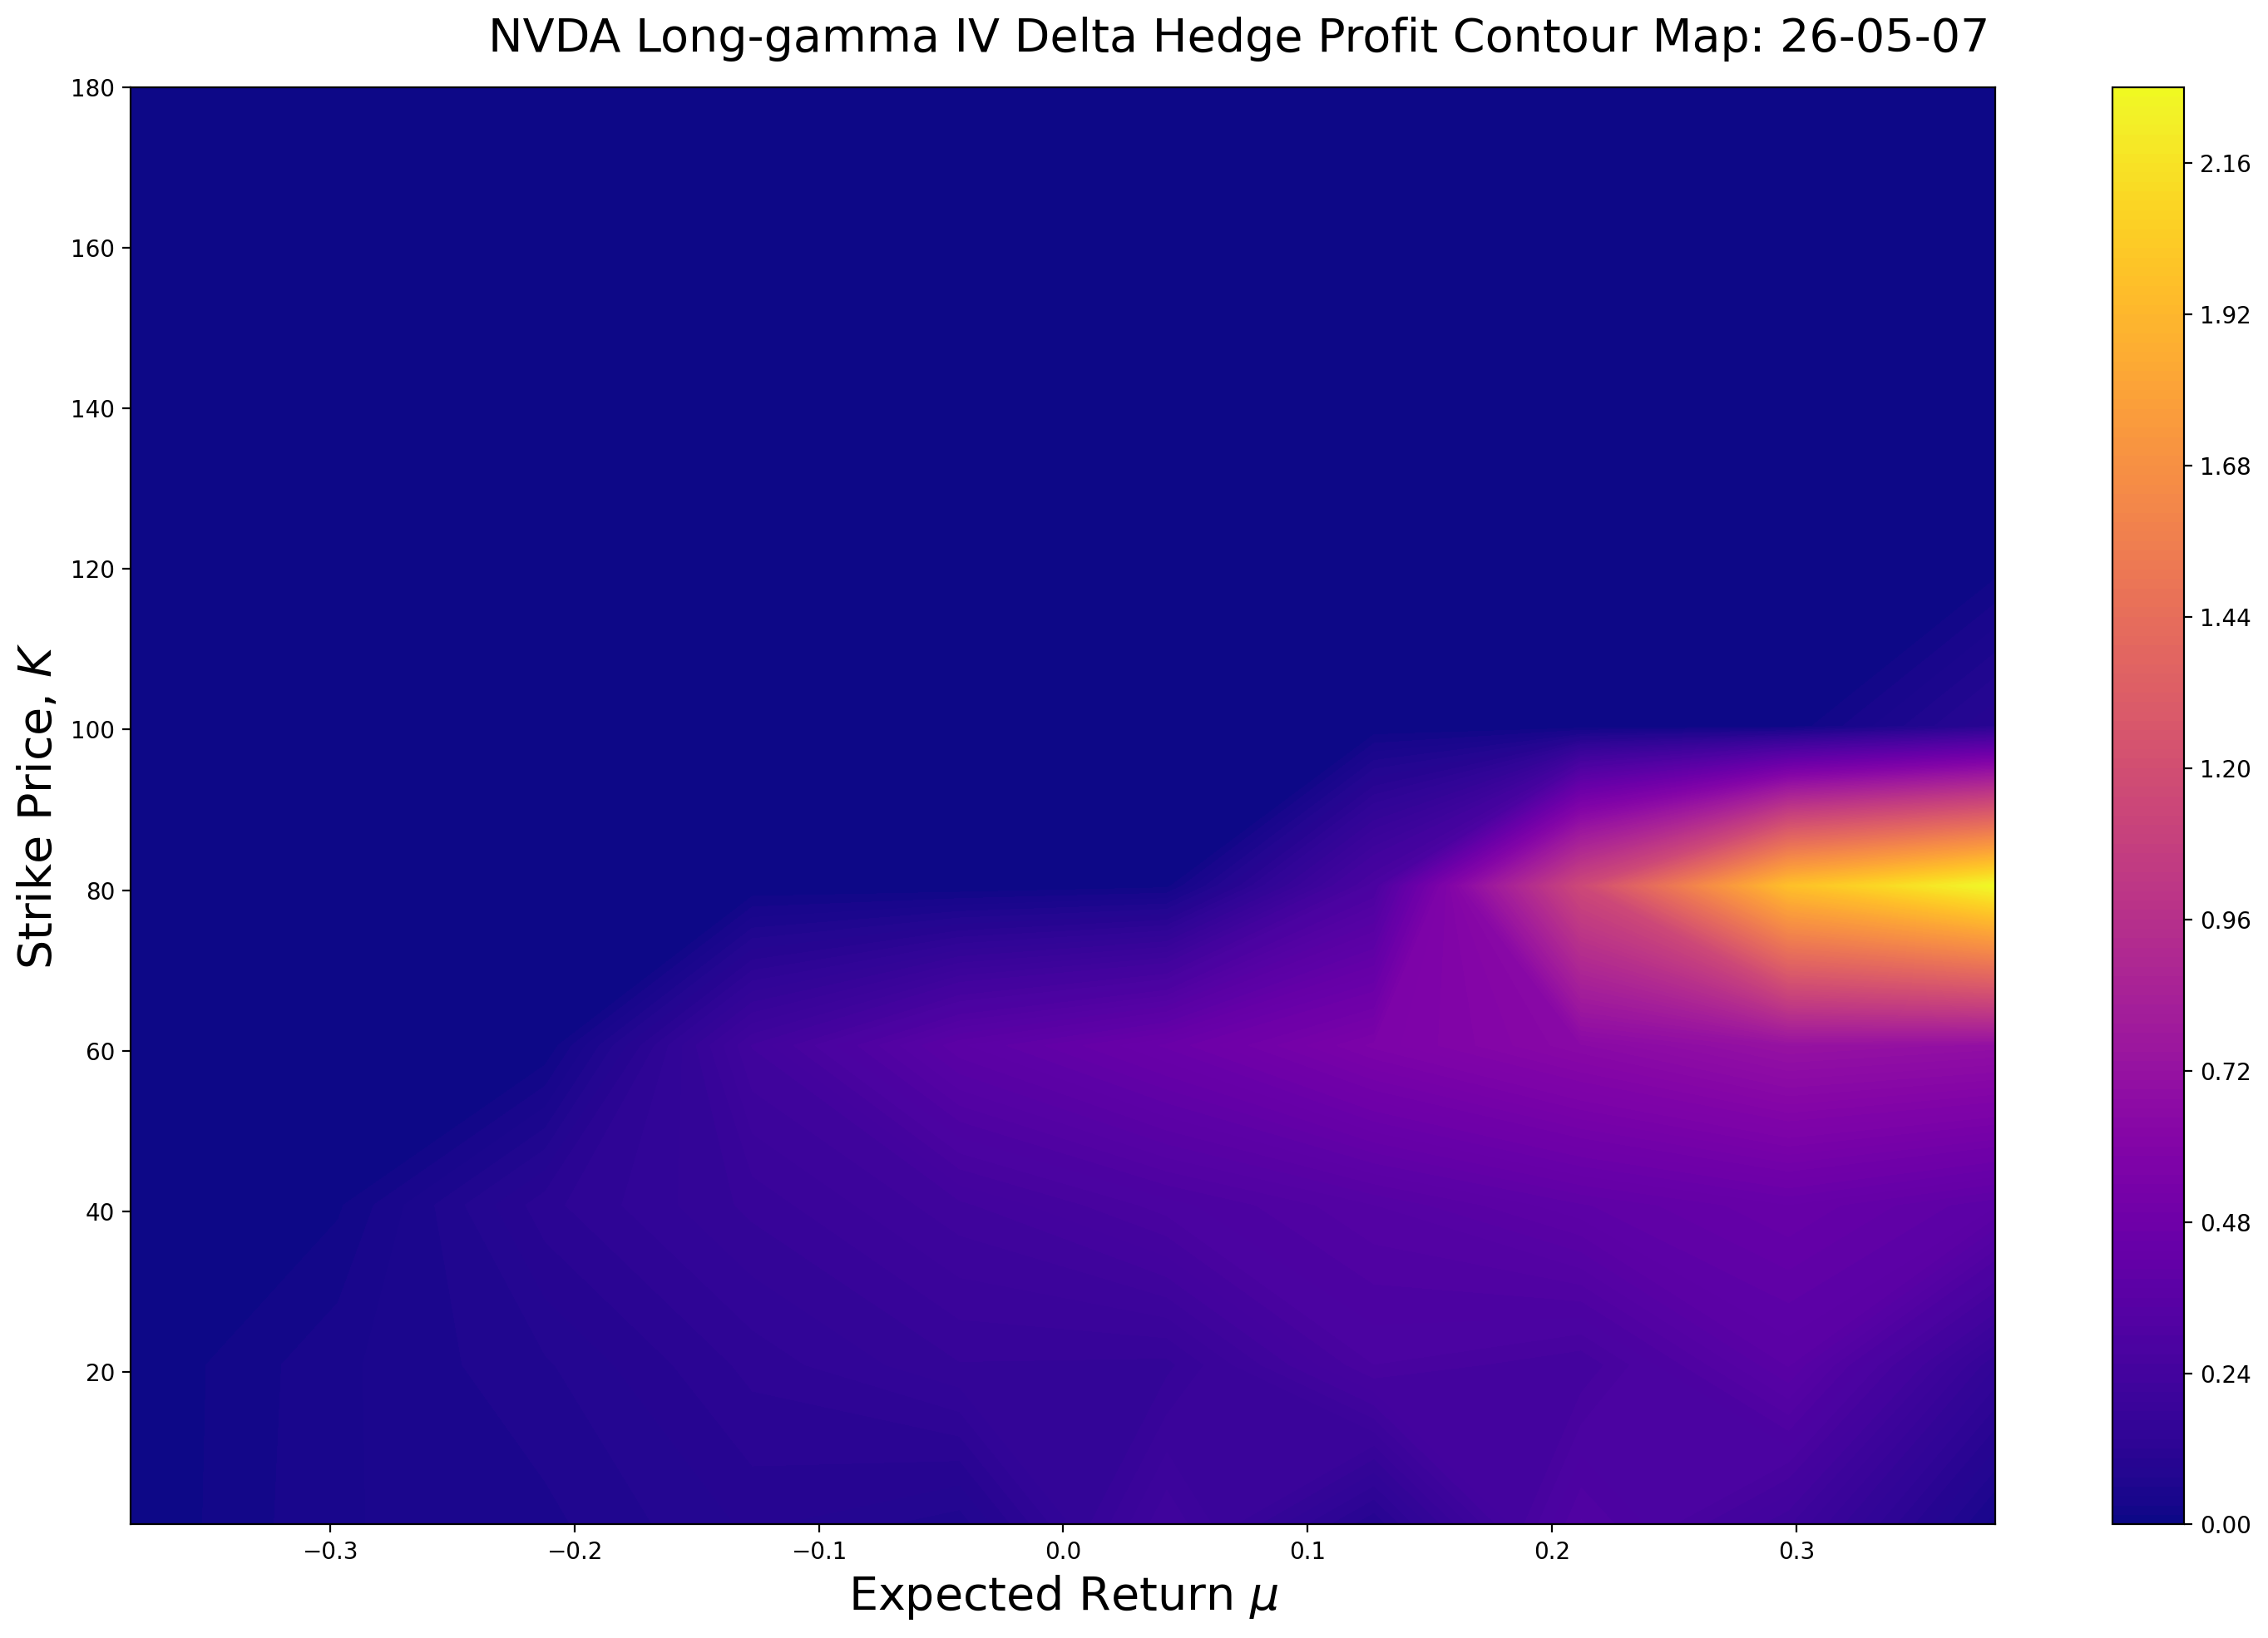

In [ ]:
fig, ax = plt.subplots(figsize = (15, 10), dpi = 200)
fig.suptitle(f'{underlying} Call Long-gamma IV Delta Hedge Profit Contour Map: {max_time}', fontsize = 20)
pnl_contour = ax.contourf(call_opt_delta_hedge['growth_rate_axis'], 
            call_opt_delta_hedge['strike_price_axis'], 
            call_opt_delta_hedge['pnl_surface'], 
            levels = 200, 
            cmap = 'plasma')
ax.set_xlabel(r'Expected Return $\mu$', fontsize = 20)
ax.set_ylabel(r'Strike Price, $K$', fontsize = 20)
fig.colorbar(pnl_contour)
plt.tight_layout();